# 49 — Comparative video-classification experiment

This final Lecture 10 notebook compares several ways to represent and classify the same videos:

- temporal averaging with a 2D CNN;
- early fusion by stacking frames as channels;
- a 3D CNN;
- a 3D CNN with a non-local attention block;
- separate appearance and motion streams.

The purpose is not to find a universally best architecture. It is to connect information availability, inductive bias, parameter count, runtime, and accuracy under one controlled protocol.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

from cs231n_practice.video import (
    NonLocalBlock3D,
    attention_entry_counts,
    stack_frames_as_channels,
    stack_temporal_differences,
    video_to_conv3d_batch,
)

torch.manual_seed(17)
np.random.seed(17)

CLASS_NAMES = ("red-right", "red-left", "blue-right", "blue-left")
DIRECTIONS = torch.tensor([[0, 1], [0, -1]])
COLORS = torch.tensor([
    [0.90, 0.15, 0.15],
    [0.15, 0.30, 0.90],
])

## 1. A task that contains appearance and motion

Each five-frame video contains a colored square moving horizontally. Its class combines two independent properties:

- color is an appearance property visible in one frame;
- left versus right is a temporal-order property.

The label convention is `label = 2 * color_id + direction_id`. Every target trajectory is centered at frame 2, so when the target is visible that frame reveals color and location but not whether motion was leftward or rightward. To make the comparison less trivial, target contrast varies, frame noise is stronger, a static colored distractor and an independently moving gray distractor are added, and the target is occasionally hidden in one frame—including sometimes the middle frame. None of these variations determines the label.

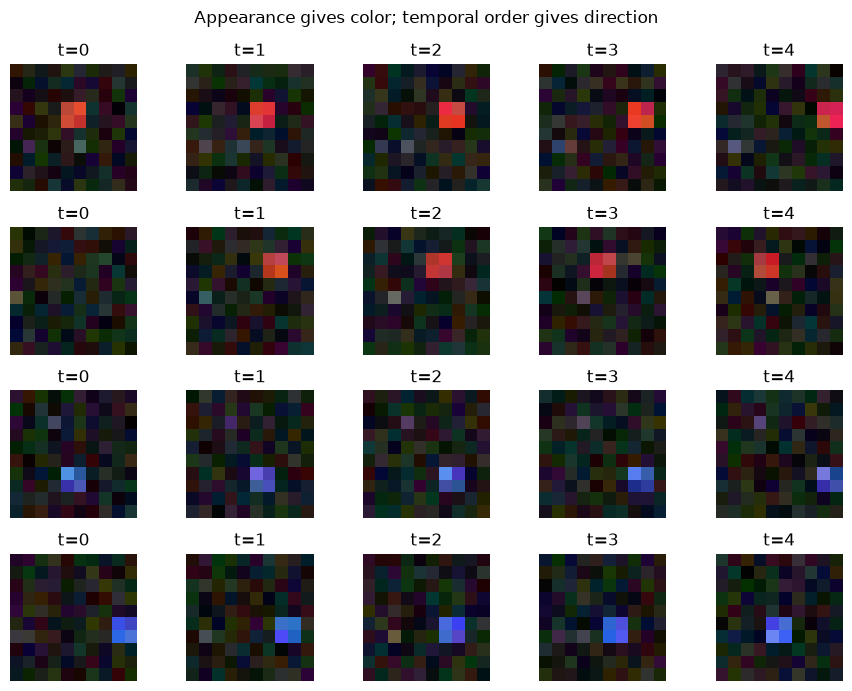

In [2]:
def make_color_direction_dataset(number_of_examples, seed, image_size=10):
    """Create RGB videos labeled by color and horizontal direction."""
    generator = torch.Generator().manual_seed(seed)
    labels = torch.arange(number_of_examples) % 4
    labels = labels[torch.randperm(number_of_examples, generator=generator)]
    videos = 0.22 * torch.rand(
        number_of_examples, 5, 3, image_size, image_size, generator=generator
    )

    for n, label in enumerate(labels):
        color_id = int(label) // 2
        direction_id = int(label) % 2
        middle_row = int(
            torch.randint(2, image_size - 3, (1,), generator=generator)
        )
        middle_column = int(
            torch.randint(2, image_size - 3, (1,), generator=generator)
        )
        row_step, column_step = DIRECTIONS[direction_id]
        target_brightness = float(
            torch.empty(1).uniform_(0.55, 0.90, generator=generator)
        )
        occluded_frame = (
            int(torch.randint(0, 5, (1,), generator=generator))
            if torch.rand((), generator=generator) < 0.20 else -1
        )

        # A small static distractor has an unrelated random color.
        static_row = int(torch.randint(0, image_size - 1, (1,), generator=generator))
        static_column = int(
            torch.randint(0, image_size - 1, (1,), generator=generator)
        )
        static_color = 0.30 * torch.rand(3, 1, 1, generator=generator)
        videos[n, :, :, static_row:static_row + 1, static_column:static_column + 1] += (
            static_color
        )

        # A faint gray distractor moves independently of the class label.
        distractor_row = int(
            torch.randint(2, image_size - 3, (1,), generator=generator)
        )
        distractor_column = int(
            torch.randint(2, image_size - 3, (1,), generator=generator)
        )
        distractor_direction = int(torch.randint(0, 2, (1,), generator=generator))
        distractor_row_step, distractor_column_step = DIRECTIONS[
            distractor_direction
        ]

        for t in range(5):
            offset = t - 2
            row = middle_row + int(row_step) * offset
            column = middle_column + int(column_step) * offset
            if t != occluded_frame:
                videos[n, t, :, row:row + 2, column:column + 2] += (
                    target_brightness * COLORS[color_id, :, None, None]
                )

            distractor_row_t = distractor_row + int(distractor_row_step) * offset
            distractor_column_t = (
                distractor_column + int(distractor_column_step) * offset
            )
            videos[
                n, t, :,
                distractor_row_t:distractor_row_t + 1,
                distractor_column_t:distractor_column_t + 1,
            ] += 0.20

    return videos.clamp_max(1.0), labels


train_videos, train_labels = make_color_direction_dataset(320, seed=3)
validation_videos, validation_labels = make_color_direction_dataset(160, seed=5)
assert train_videos.shape == (320, 5, 3, 10, 10)

example_indices = [
    int(torch.where(train_labels == class_id)[0][0]) for class_id in range(4)
]
fig, axes = plt.subplots(4, 5, figsize=(9, 7))
for row, index in enumerate(example_indices):
    for t in range(5):
        frame = train_videos[index, t].permute(1, 2, 0)
        axes[row, t].imshow(frame)
        axes[row, t].set_title(f"t={t}")
        axes[row, t].axis("off")
    axes[row, 0].set_ylabel(CLASS_NAMES[row])
fig.suptitle("Appearance gives color; temporal order gives direction")
plt.tight_layout()
plt.show()

## 2. Temporal averaging deliberately loses order

Averaging frames produces one image and is invariant to their order. A video and the same frames played backward therefore have identical averages. The baseline can learn red versus blue, but it should confuse right with left because those trajectories contain the same frames in reverse order.

This is not a failure of optimization: the missing direction information was removed by the representation before the classifier received it.

### Exercise 1 — Verify reversal invariance

In [4]:
train_videos[example_indices[0]].shape

torch.Size([5, 3, 10, 10])

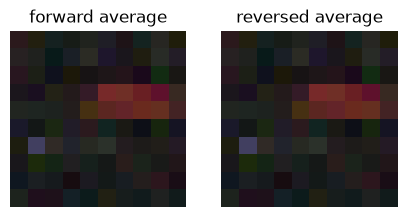

In [6]:
example_video = train_videos[example_indices[0]]

# reverse the time axis without changing any other axis.
reversed_video = torch.flip(example_video, dims=[0])
# average each video over time.
forward_average = torch.mean(example_video, dim=0)
reversed_average = torch.mean(reversed_video, dim=0)

assert not torch.equal(example_video, reversed_video)
torch.testing.assert_close(forward_average, reversed_average)

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
axes[0].imshow(forward_average.permute(1, 2, 0))
axes[0].set_title("forward average")
axes[1].imshow(reversed_average.permute(1, 2, 0))
axes[1].set_title("reversed average")
for axis in axes:
    axis.axis("off")
plt.show()

## 3. Prepare a common set of representations

The models receive different views of exactly the same underlying videos:

- temporal mean: `(N,C,H,W)`;
- early fusion: `(N,TC,H,W)`;
- 3D models: `(N,C,T,H,W)`;
- two-stream appearance: the middle frame `(N,C,H,W)`;
- two-stream motion: stacked differences `(N,(T-1)C,H,W)`.

The early-fusion channels retain frame order, unlike a mean. The two-stream representation explicitly separates what the object looks like from how pixels change.

### Exercise 2 — Construct every model input

In [8]:
train_videos.shape

torch.Size([320, 5, 3, 10, 10])

In [15]:
def prepare_video_representations(videos):
    """Return the five representations used in this experiment."""
    N, T, C, H, W = videos.shape
    # average over only the time dimension.
    temporal_mean = torch.mean(videos, dim=1)
    # use the reusable layout helpers.
    early_fusion = stack_frames_as_channels(videos) # torch.reshape(videos, (N, T*C, H, W))
    conv3d = video_to_conv3d_batch(videos)
    # select the middle frame and stack adjacent differences.
    appearance = videos[:, T // 2]
    motion = stack_temporal_differences(videos)
    return {
        "temporal_mean": temporal_mean,
        "early_fusion": early_fusion,
        "conv3d": conv3d,
        "appearance": appearance,
        "motion": motion,
    }


train_inputs = prepare_video_representations(train_videos)
validation_inputs = prepare_video_representations(validation_videos)

assert train_inputs["temporal_mean"].shape == (320, 3, 10, 10)
assert train_inputs["early_fusion"].shape == (320, 15, 10, 10)
assert train_inputs["conv3d"].shape == (320, 3, 5, 10, 10)
assert train_inputs["appearance"].shape == (320, 3, 10, 10)
assert train_inputs["motion"].shape == (320, 12, 10, 10)

## 4. Models with different temporal biases

The 2D encoder is shared by the temporal-mean, early-fusion, and two-stream classifiers. The two 3D models share the same stem and head. Their stem downsamples only space:

`(N,3,5,10,10) → (N,6,5,5,5)`.

The non-local block therefore attends over `5·5·5=125` positions instead of all 500 input positions. Downsampling before global attention is a common practical compromise.

In [16]:
class SpatialEncoder(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(input_channels, 6, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(6, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        return self.network(x).flatten(1)


class ImageLikeClassifier(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.encoder = SpatialEncoder(input_channels)
        self.classifier = nn.Linear(8, 4)

    def forward(self, x):
        return self.classifier(self.encoder(x))


full_joint, _ = attention_entry_counts(5, 10, 10)
downsampled_joint, _ = attention_entry_counts(5, 5, 5)
print(f"Joint-attention entries before stem: {full_joint:,}")
print(f"Joint-attention entries after stem:  {downsampled_joint:,}")
print(f"Reduction: {full_joint / downsampled_joint:.1f}×")

Joint-attention entries before stem: 250,000
Joint-attention entries after stem:  15,625
Reduction: 16.0×


### Exercise 3 — Complete the 3D classifier forward pass

The optional non-local block receives the downsampled 3D feature map. When disabled, `nn.Identity` leaves it unchanged. Both variants then use the same local 3D head and classifier.

In [19]:
class Small3DClassifier(nn.Module):
    def __init__(self, use_nonlocal=False):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv3d(
                3, 6, kernel_size=3, padding=1, stride=(1, 2, 2)
            ),
            nn.ReLU(),
        )
        self.context = (
            NonLocalBlock3D(channels=6, attention_channels=3)
            if use_nonlocal else nn.Identity()
        )
        self.head = nn.Sequential(
            nn.Conv3d(6, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d(1),
        )
        self.classifier = nn.Linear(8, 4)

    def forward(self, x):
        # apply stem, optional context, head, flatten, and classifier.
        # input (4, 3, 5, 10, 10) -> stem (4, 6, 5, 5, 5)
        stem_features = self.stem(x)
        # stem (4, 6, 5, 5, 5) -> context (4, 6, 5, 5, 5)
        contex_features = self.context(stem_features)
        # context (4, 6, 5, 5, 5) -> head Conv3d (4, 8, 5, 5, 5)
        # head Conv3d (4, 8, 5, 5, 5) -> AdaptiveAvgPool3d(1) (4, 8, 1, 1, 1)
        head_features = self.head(contex_features)
        # AdaptiveAvgPool3d(1) (4, 8, 1, 1, 1) -> flatten from axis 1 (4, 8)
        head_flatten_features = head_features.flatten(1)
        # flatten from axis 1 (4, 8) -> Linear(8, 4) (4, 4)
        logits = self.classifier(head_flatten_features)
        return logits


sample_3d = train_inputs["conv3d"][:4]
assert Small3DClassifier()(sample_3d).shape == (4, 4)
assert Small3DClassifier(use_nonlocal=True)(sample_3d).shape == (4, 4)

### Exercise 4 — Complete the two-stream classifier

Each encoder produces eight features. Concatenating along the feature axis gives 16 features per video, which the final classifier maps to four class scores.

In [21]:
class TwoStreamVideoClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.appearance_encoder = SpatialEncoder(input_channels=3)
        self.motion_encoder = SpatialEncoder(input_channels=12)
        self.classifier = nn.Linear(16, 4)

    def forward(self, appearance, motion):
        # encode both inputs and concatenate their feature vectors.
        appearance_features = self.appearance_encoder(appearance)
        motion_features = self.motion_encoder(motion)
        fused_features = torch.cat(
            (appearance_features,motion_features), dim=1
        )
        return self.classifier(fused_features)


two_stream = TwoStreamVideoClassifier()
sample_logits = two_stream(
    train_inputs["appearance"][:4],
    train_inputs["motion"][:4],
)
assert sample_logits.shape == (4, 4)

## 5. Train every model under one protocol

All models use the same examples, labels, optimizer, learning rate, iteration count, and initialization seed. This makes the comparison controlled, although it does not guarantee that every architecture receives its individually optimal hyperparameters.

Wall-clock time is measured only as a rough local comparison. It depends on hardware, thread settings, and library implementations, so do not treat it as a universal benchmark.

In [29]:
def train_model(model, inputs, labels, iterations=50, learning_rate=2e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_history = []
    model.train()
    start_time = time.perf_counter()
    for _ in range(iterations):
        logits = model(*inputs) if isinstance(inputs, tuple) else model(inputs)
        loss = F.cross_entropy(logits, labels)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        loss_history.append(float(loss.detach()))
    elapsed = time.perf_counter() - start_time
    return loss_history, elapsed


def evaluate(model, inputs, labels):
    model.eval()
    with torch.no_grad():
        logits = model(*inputs) if isinstance(inputs, tuple) else model(inputs)
        predictions = logits.argmax(dim=1)
    accuracy = float((predictions == labels).float().mean())
    return accuracy, predictions


def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters())


setups = (
    (
        "temporal mean",
        lambda: ImageLikeClassifier(3),
        train_inputs["temporal_mean"],
        validation_inputs["temporal_mean"],
    ),
    (
        "early fusion",
        lambda: ImageLikeClassifier(15),
        train_inputs["early_fusion"],
        validation_inputs["early_fusion"],
    ),
    (
        "3D CNN",
        lambda: Small3DClassifier(),
        train_inputs["conv3d"],
        validation_inputs["conv3d"],
    ),
    (
        "3D + non-local",
        lambda: Small3DClassifier(use_nonlocal=True),
        train_inputs["conv3d"],
        validation_inputs["conv3d"],
    ),
    (
        "two-stream",
        TwoStreamVideoClassifier,
        (train_inputs["appearance"], train_inputs["motion"]),
        (validation_inputs["appearance"], validation_inputs["motion"]),
    ),
)

results = {}
for name, make_model, model_train_inputs, model_validation_inputs in setups:
    torch.manual_seed(10)
    model = make_model()
    history, elapsed = train_model(model, model_train_inputs, train_labels)
    model_accuracy, predictions = evaluate(
        model, model_validation_inputs, validation_labels
    )
    results[name] = {
        "model": model,
        "loss_history": history,
        "seconds": elapsed,
        "parameters": parameter_count(model),
        "accuracy": model_accuracy,
        "predictions": predictions,
    }
    print(
        f"{name:>14}: accuracy={model_accuracy:.3f}, "
        f"parameters={results[name]['parameters']:,}, time={elapsed:.2f}s"
    )

 temporal mean: accuracy=0.519, parameters=644, time=0.63s
  early fusion: accuracy=0.663, parameters=1,292, time=0.70s
        3D CNN: accuracy=0.750, parameters=1,832, time=0.59s
3D + non-local: accuracy=0.788, parameters=1,920, time=1.75s
    two-stream: accuracy=0.988, parameters=1,770, time=1.38s


## 6. Compare optimization, accuracy, size, and runtime

The temporal-mean model should remain around 50%: it can identify color but cannot recover direction after order has been discarded. The other representations retain temporal order, but stronger noise, occlusion, and unrelated motion make their different inductive biases and optimization behavior visible.

Perfect accuracy here does not establish that one architecture is best for real video. This dataset is small and deliberately structured; the comparison reveals representational capability and computational trade-offs rather than real-world ranking.

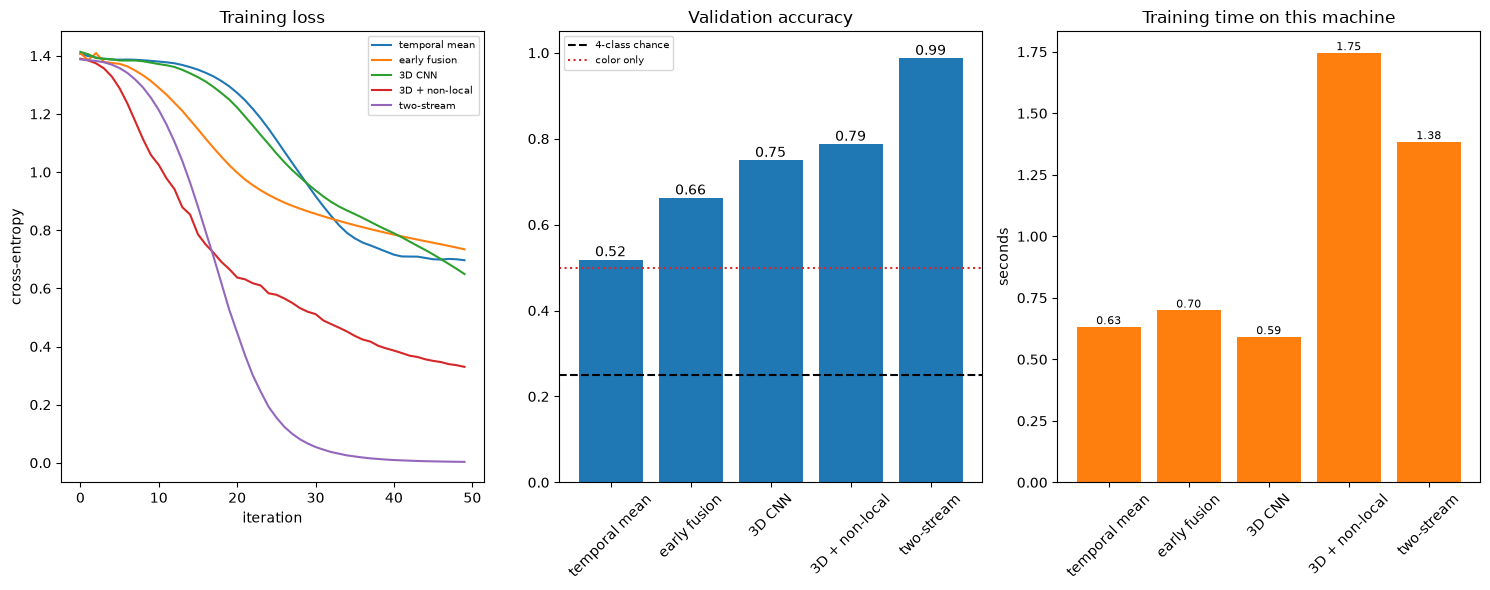


Parameter counts
 temporal mean: 644
  early fusion: 1,292
        3D CNN: 1,832
3D + non-local: 1,920
    two-stream: 1,770


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for name, result in results.items():
    axes[0].plot(result["loss_history"], label=name)
axes[0].set_title("Training loss")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("cross-entropy")
axes[0].legend(fontsize=7)

names = list(results)
accuracies = [results[name]["accuracy"] for name in names]
bars = axes[1].bar(names, accuracies, color="tab:blue")
axes[1].axhline(0.25, color="black", linestyle="--", label="4-class chance")
axes[1].axhline(0.50, color="tab:red", linestyle=":", label="color only")
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Validation accuracy")
axes[1].tick_params(axis="x", rotation=45)
axes[1].bar_label(bars, fmt="%.2f")
axes[1].legend(fontsize=7)

seconds = [results[name]["seconds"] for name in names]
bars = axes[2].bar(names, seconds, color="tab:orange")
axes[2].set_title("Training time on this machine")
axes[2].set_ylabel("seconds")
axes[2].tick_params(axis="x", rotation=45)
axes[2].bar_label(bars, fmt="%.2f", fontsize=8)

plt.tight_layout()
plt.show()

print("\nParameter counts")
for name in names:
    print(f"{name:>14}: {results[name]['parameters']:,}")

## 7. Compare class-specific errors

Rows are true classes and columns are predictions. The temporal-mean baseline should mainly confuse the two directions within each color. Models with temporal information should concentrate more counts on the diagonal.

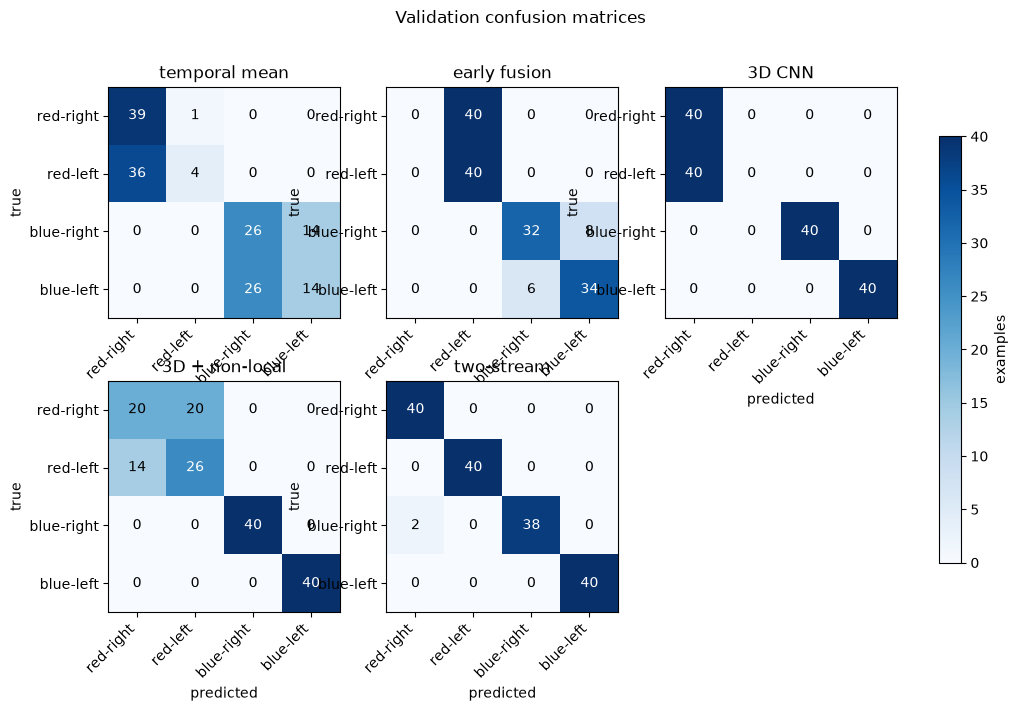

In [31]:
def confusion_matrix(targets, predictions, number_of_classes=4):
    combined = targets * number_of_classes + predictions
    return torch.bincount(
        combined, minlength=number_of_classes**2
    ).reshape(number_of_classes, number_of_classes)


fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for axis, name in zip(axes.flat, names):
    matrix = confusion_matrix(validation_labels, results[name]["predictions"])
    image_handle = axis.imshow(matrix, cmap="Blues", vmin=0, vmax=40)
    axis.set_title(name)
    axis.set_xticks(range(4), CLASS_NAMES, rotation=45, ha="right")
    axis.set_yticks(range(4), CLASS_NAMES)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    for row in range(4):
        for column in range(4):
            count = int(matrix[row, column])
            axis.text(
                column, row, count,
                ha="center", va="center",
                color="white" if count > 20 else "black",
            )
axes.flat[-1].axis("off")
fig.colorbar(image_handle, ax=axes, fraction=0.025, label="examples")
fig.suptitle("Validation confusion matrices")
plt.show()

### Why might direction be learned for only one color?

The classes are exactly balanced, and the same asymmetric errors appear on both training and validation data, so this is not caused by class frequency or ordinary overfitting. The four-class objective does not tell a model that the labels factor into `color × direction`. A small model can therefore find a partial solution: learn color, then learn a color-specific direction feature for only one color while collapsing the other color's two directions. Noise, distractors, limited capacity, and short training make this solution easier to reach.

The favored color can change with the initialization seed, so the pattern is not an inherent property of red or blue. Comparing multiple seeds—or using separate color and direction heads—would give a more reliable architectural conclusion. The two-stream model is less affected here because its explicit difference input makes direction easier to isolate from appearance.

## 8. What this comparison does and does not show

- Temporal averaging is efficient but intentionally discards order.
- Early fusion can learn order from channel identity, but its input width depends on a fixed clip length.
- A 3D CNN has a local space-time bias and naturally accepts video layout.
- A non-local block adds global interaction, but its attention matrix increases runtime and memory; it need not improve an already easy local-motion task.
- Two-stream processing makes appearance and change explicit, but frame differences remain sensitive to noise and are not optical flow. Its strong result here reflects how closely the representation matches this synthetic task.

Real conclusions require larger datasets, tuned hyperparameters, repeated runs, and evaluation across different video tasks. Architecture choice depends on whether labels require short motion, long-range context, fine spatial detail, or multimodal information.

## Reflection

1. Why can the temporal-mean model identify color but not direction?
2. Why does early fusion preserve temporal order even though it uses a 2D CNN?
3. What inductive bias distinguishes a 3D CNN from early fusion?
4. Why downsample before applying the non-local block?
5. Why might the non-local model fail to outperform the plain 3D CNN here?
6. What complementary information is supplied to the two streams?
7. Why are parameter count and training time different kinds of model cost?
8. Which results from this synthetic experiment should not be generalized directly to real video datasets?
9. What does learning direction for only one color reveal about a single training run?
10. Why does the two-stream model's strong result not prove that it is universally best?

### Answers

1. Color survives temporal averaging, but frame order does not, so reversed directions can produce the same averaged input.
2. Each frame occupies a fixed group of input channels. A 2D convolution can learn different weights for channels belonging to early and late frames, so swapping frames changes its input even though it has no explicit time axis. The drawback is that its input width is tied to a fixed clip length.
3. An inductive bias is an architectural preference for certain patterns or solutions. A 3D convolution assumes that useful patterns are local in time and space and applies the same kernel at different space-time positions. Early fusion instead treats time as input-channel identity and mixes the fixed set of frames immediately in its first 2D layer.
4. Joint attention has quadratic cost in the number of positions. Spatial downsampling reduces the token count from 500 to 125 here, reducing each per-example attention matrix from 250,000 to 15,625 entries—a 16-fold reduction—while retaining all five time steps.
5. This task mainly requires short local motion, so global attention may add little while making optimization more difficult. Extra capacity does not guarantee better accuracy.
6. The appearance stream emphasizes color and spatial content; the difference stream emphasizes change and direction but is more sensitive to frame noise.
7. Parameter count measures stored learned values and partly reflects model capacity. Training time also depends on operations, activation sizes, data movement, hardware, and implementation. Attention can therefore be slower and use more temporary memory even when it adds relatively few parameters.
8. Do not generalize the exact accuracies, runtimes, ranking, or error patterns: the dataset is tiny and synthetic, and the experiment uses one seed and one shared training setup.
9. It shows that one seed can lead to a partial, entangled solution: color is learned, but direction becomes color-specific. Another initialization can favor the other color or reach a better solution, so architectural claims should use repeated runs and report variation.
10. The representation closely matches how this synthetic task was generated: appearance provides color and differences expose direction. Real motion may include camera movement, deformation, illumination changes, occlusion, and noisy flow, so 3D or attention-based models may be more suitable on other tasks.